<a href="https://colab.research.google.com/github/nihaar06/Deep_Learning/blob/main/CNN/road_damage_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import kagglehub
path = kagglehub.dataset_download("lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes")

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.


In [44]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of the dataset directory '{path}':")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


Streaming output truncated to the last 5000 lines.
            vlcsnap-2025-02-18-23h12m22s604.txt
            vlcsnap-2025-02-19-16h22m29s339.txt
            vlcsnap-2025-02-18-23h25m48s850.txt
            vlcsnap-2025-02-19-14h42m40s085.txt
            vlcsnap-2025-02-18-18h35m43s212.txt
            vlcsnap-2025-02-19-16h24m19s410.txt
            vlcsnap-2025-02-26-20h42m08s749.txt
            vlcsnap-2025-02-19-14h49m38s907.txt
            vlcsnap-00062.txt
            vlcsnap-2025-02-19-17h02m53s135.txt
            vlcsnap-2025-02-18-18h45m09s626.txt
            vlcsnap-2025-02-19-14h30m24s704.txt
            vlcsnap_2025-03-16-15h18m28s053.txt
            vlcsnap-2025-02-19-15h05m48s501.txt
            vlcsnap-2025-02-18-17h03m26s001.txt
            vlcsnap-2025-02-18-18h32m48s578.txt
            vlcsnap-2025-02-18-23h29m08s868.txt
            vlcsnap_2025-03-16-15h24m09s426.txt
            vlcsnap-2025-02-18-18h32m56s495.txt
            vlcsnap-2025-02-19-14h29m46s948.txt
       

This dataset appears to contain images. Let's load a sample image to visualize it. We'll use the `PIL` (Pillow) library for image processing.

Loading sample image from: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/images/vlcsnap-2025-02-19-15h10m43s692.jpg


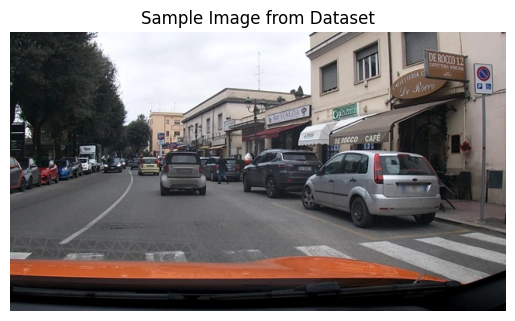

In [45]:
from PIL import Image
import matplotlib.pyplot as plt

# Corrected path: images folder is inside the 'data' subdirectory
image_folder = os.path.join(path, 'data', 'images')

# Find the first image file in the folder
first_image_path = None
if os.path.exists(image_folder):
    for filename in os.listdir(image_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            first_image_path = os.path.join(image_folder, filename)
            break

if first_image_path:
    print(f"Loading sample image from: {first_image_path}")
    try:
        img = Image.open(first_image_path)
        plt.imshow(img)
        plt.title('Sample Image from Dataset')
        plt.axis('off') # Hide axes ticks
        plt.show()
    except Exception as e:
        print(f"Error loading image: {e}")
else:
    print(f"No image files found in '{image_folder}'. Please check the directory structure.")


### Task 1: Dataset Understanding
In this section, we will analyze the dataset to identify classes, check for imbalance, and understand image properties.

In [46]:
import pandas as pd
import glob

# Define paths
image_files = glob.glob(os.path.join(path, 'data/images/*.jpg'))
label_files = glob.glob(os.path.join(path, 'data/labels-YOLO/*.txt'))

print(f"Total Images: {len(image_files)}")
print(f"Total Label Files: {len(label_files)}")

# Check image dimensions of a sample
with Image.open(image_files[0]) as img:
    print(f"Sample Image Dimensions: {img.size} (Width, Height)")

# Analyzing classes from YOLO labels
# YOLO format: <class_id> <x_center> <y_center> <width> <height>
class_counts = {}
for label_path in label_files:
    with open(label_path, 'r') as f:
        for line in f:
            class_id = line.split()[0]
            class_counts[class_id] = class_counts.get(class_id, 0) + 1

# Convert to DataFrame for better visualization
df_classes = pd.DataFrame(list(class_counts.items()), columns=['Class_ID', 'Count']).sort_values('Class_ID')
print("\nClass Distribution (from YOLO labels):")
display(df_classes)

Total Images: 2009
Total Label Files: 2009
Sample Image Dimensions: (640, 360) (Width, Height)

Class Distribution (from YOLO labels):


,Class_ID,Count
2,0,1261
1,1,2519
0,2,957


In [47]:
# Read README to find class definitions
readme_path = os.path.join(path, 'data/README.md')
if os.path.exists(readme_path):
    with open(readme_path, 'r') as f:
        print("Dataset Metadata (Class Definitions):")
        print(f.read())
else:
    print("README not found. Checking conversion scripts for class mappings...")
    script_path = os.path.join(path, 'data/YOLO-conversion-script.py')
    with open(script_path, 'r') as f:
        # Look for class lists in the script
        lines = f.readlines()
        for line in lines:
            if 'classes' in line.lower() or 'names' in line.lower():
                print(line.strip())

Dataset Metadata (Class Definitions):
# Road Damage Dataset: Potholes, Cracks, and Manholes

This dataset contains images of road surfaces with potholes, cracks, and manholes, along with polygon-based, YOLO-compatible, and COCO JSON annotations. It is intended for object detection research and evaluation.

## Dataset Structure

```
annotations_coco.json
COCO-conversion-script.py
images/
labels/
labels-YOLO/
README.md
YOLO-conversion-script.py
```

- **images/**: contains all the images in JPG format.
- **labels/**: original polygon-based annotations. Each `.txt` file corresponds to an image and contains one line per object: `class_id x1 y1 x2 y2 x3 y3 x4 y4`

  - Coordinates are normalized in `[0,1]`.
  - Four points define the quadrilateral around each object (ordered and convex).

- **labels-YOLO/**: axis-aligned bounding boxes in YOLO format `(class_id, x_center, y_center, width, height)`, ready for YOLO training.
- **annotations_coco.json**: dataset annotations in COCO format, with

### Task 2: Data Preprocessing
Now we will prepare the data for the CNN. This involves:
1.  **Resizing** images to a standard size (e.g., 224x224).
2.  **Normalization** (scaling pixel values to 0-1).
3.  **Train/Test Split**.
4.  **Label Encoding**.

In [48]:
import numpy as np
from sklearn.model_selection import train_test_split
import cv2

def load_and_preprocess_data(image_files, target_size=(128, 128)):
    images = []
    labels = []

    # For classification, we will use the first class found in the YOLO txt file as the primary label
    for img_path in image_files[:1000]: # Using a subset for faster processing in this step
        label_path = img_path.replace('images', 'labels-YOLO').replace('.jpg', '.txt')
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                first_line = f.readline()
                if first_line:
                    class_id = int(first_line.split()[0])

                    # Load and resize image
                    img = cv2.imread(img_path)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, target_size)

                    images.append(img)
                    labels.append(class_id)

    return np.array(images), np.array(labels)

print("Loading and preprocessing a subset of data...")
X, y = load_and_preprocess_data(image_files)

# Normalization
X = X.astype('float32') / 255.0

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Loading and preprocessing a subset of data...
X_train shape: (800, 128, 128, 3)
X_test shape: (200, 128, 128, 3)


### Task 3: Data Augmentation
Augmentation is critical for training robust CNNs because it:
1. **Reduces Overfitting**: Prevents the model from memorizing specific training images.
2. **Improves Generalization**: Exposes the model to variations (lighting, angles) it might encounter in the real world.
3. **Handles Imbalance**: Can help the model learn more features from minority classes.

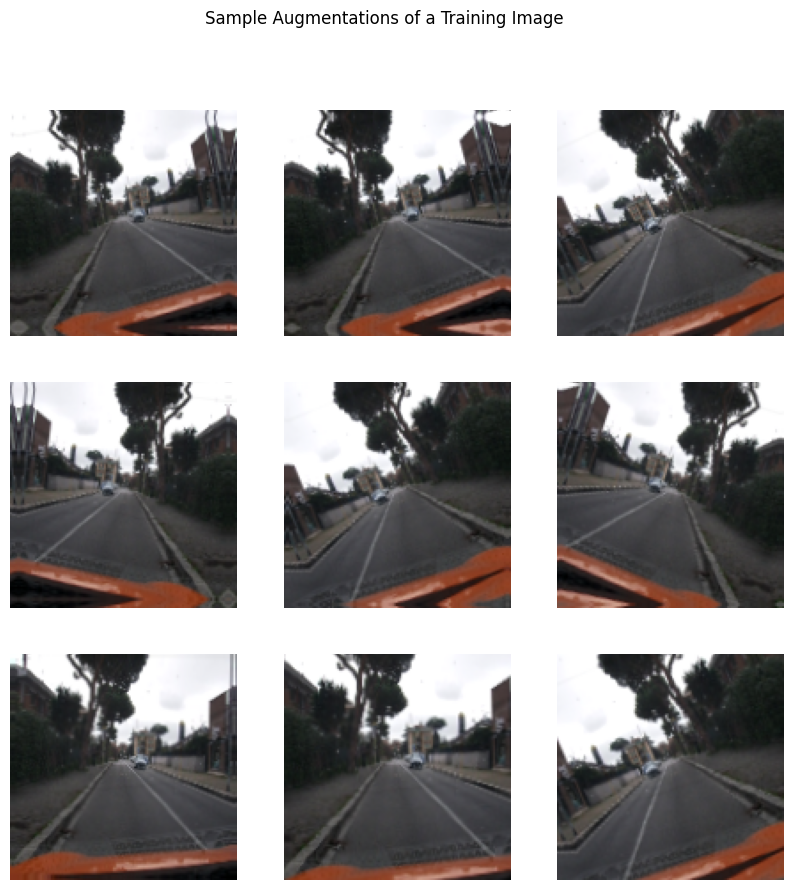

In [49]:
import tensorflow as tf
from tensorflow.keras import layers

# Define the augmentation pipeline using Keras Preprocessing Layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Visualization of augmented samples
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_image = data_augmentation(tf.expand_dims(X_train[0], 0))
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0])
    plt.axis("off")
plt.suptitle("Sample Augmentations of a Training Image")
plt.show()

### Task 4: CNN Architecture Design
We will now build a custom CNN architecture. The model uses:
1. **Convolutional Layers**: To extract spatial features like edges and textures.
2. **MaxPooling Layers**: To reduce dimensionality and computational load.
3. **Dropout**: To improve generalization by randomly silencing neurons during training.
4. **Dense Layers**: To perform the final classification based on extracted features.

In [50]:
from tensorflow.keras import Sequential, layers

num_classes = 3 # Pothole, Crack, Manhole

model = Sequential([
    # Input layer with augmentation
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Task 5: Model Training
We will train the model using the training data with a validation split. We'll monitor both loss and accuracy.

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4703 - loss: 1.0734 - val_accuracy: 0.4812 - val_loss: 1.0460
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5094 - loss: 1.0412 - val_accuracy: 0.4812 - val_loss: 1.0513
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5078 - loss: 1.0534 - val_accuracy: 0.4812 - val_loss: 1.0435
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5094 - loss: 1.0433 - val_accuracy: 0.4812 - val_loss: 1.0481
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5094 - loss: 1.0278 - val_accuracy: 0.4812 - val_loss: 1.0420
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5094 - loss: 1.0236 - val_accuracy: 0.4812 - val_loss: 1.0206
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5109 - loss: 1.0240 - val_accuracy: 0.4812 - val_loss: 1.0284
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5094 - loss: 1.0047 - val_accuracy: 0.4812 - v

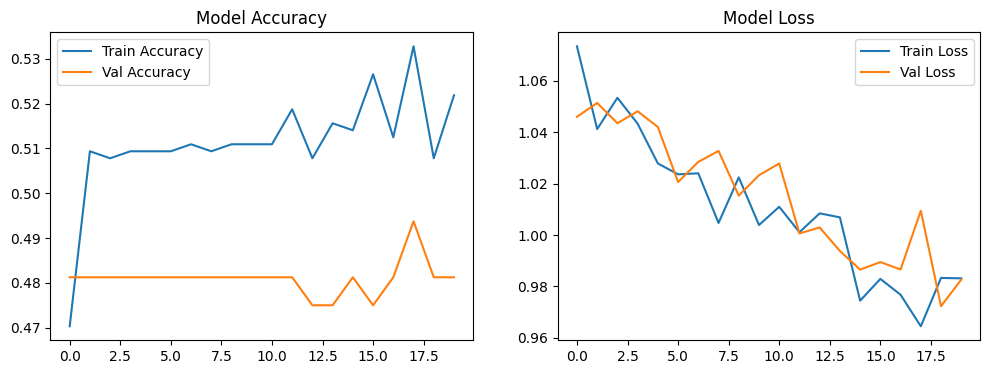

In [51]:
# Training the model
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

# Plotting training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

### Task 6 & 7: Model Evaluation and Error Analysis
In this step, we evaluate the model on the unseen test set and analyze the confusion matrix to identify specific class failures.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Classification Report:
              precision    recall  f1-score   support

     Pothole       0.62      0.11      0.19        45
       Crack       0.52      0.97      0.68       103
     Manhole       0.00      0.00      0.00        52

    accuracy                           0.53       200
   macro avg       0.38      0.36      0.29       200
weighted avg       0.41      0.53      0.39       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


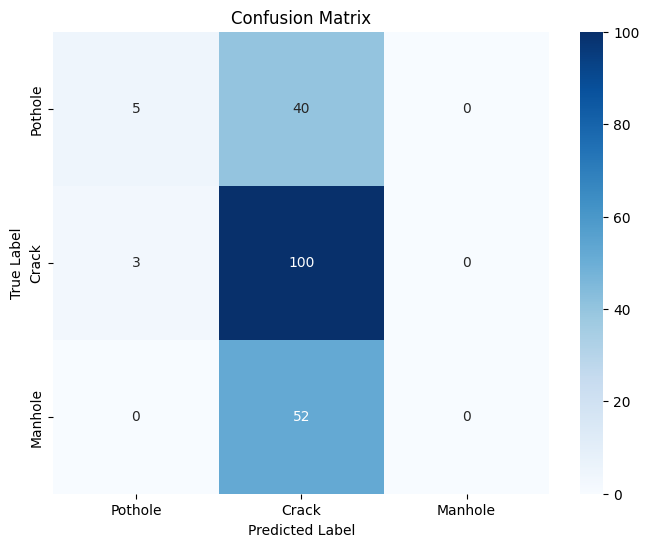

In [52]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Define class names
class_names = ['Pothole', 'Crack', 'Manhole']

# Task 6: Accuracy, Precision, Recall, F1 Score
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Task 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Task 5: Model Training
We will train the model using the training data with a validation split. We'll monitor both loss and accuracy.

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5266 - loss: 0.9734 - val_accuracy: 0.4812 - val_loss: 0.9947
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5359 - loss: 0.9565 - val_accuracy: 0.4938 - val_loss: 0.9886
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5422 - loss: 0.9629 - val_accuracy: 0.5063 - val_loss: 0.9671
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5422 - loss: 0.9525 - val_accuracy: 0.4938 - val_loss: 0.9816
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5172 - loss: 0.9417 - val_accuracy: 0.5000 - val_loss: 1.0897
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5391 - loss: 0.9442 - val_accuracy: 0.5000 - val_loss: 1.1671
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5547 - loss: 0.9498 - val_accuracy: 0.5000 - val_loss: 1.0374
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5297 - loss: 0.9350 - val_accuracy: 0.5188 - v

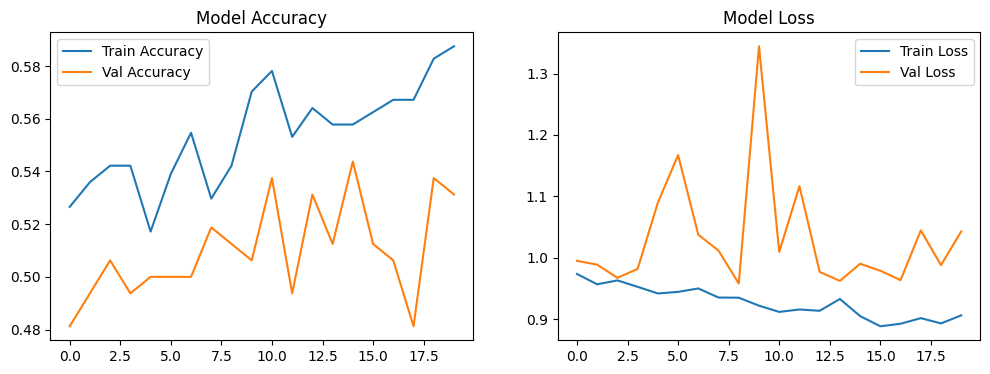

In [53]:
# Training the model
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

# Plotting training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

### Task 6 & 7: Model Evaluation and Error Analysis
In this step, we evaluate the model on the unseen test set and analyze the confusion matrix to identify specific class failures.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Classification Report:
              precision    recall  f1-score   support

     Pothole       0.44      0.18      0.25        45
       Crack       0.55      0.90      0.68       103
     Manhole       0.46      0.12      0.18        52

    accuracy                           0.54       200
   macro avg       0.49      0.40      0.37       200
weighted avg       0.50      0.54      0.46       200



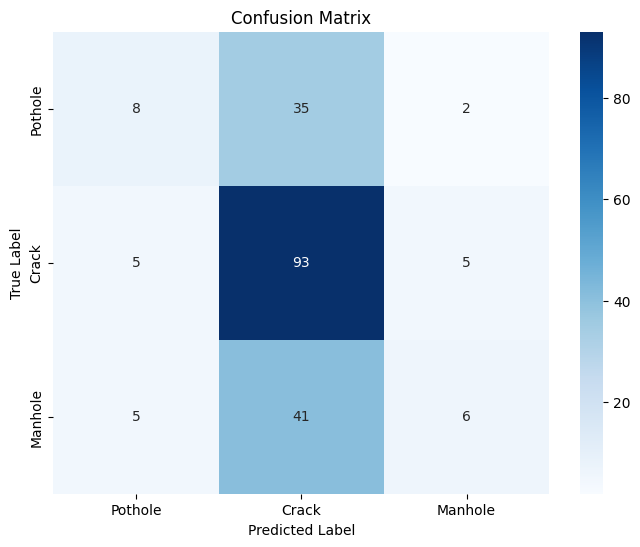

In [54]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Define class names
class_names = ['Pothole', 'Crack', 'Manhole']

# Task 6: Accuracy, Precision, Recall, F1 Score
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Task 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Task 7: Failure Analysis (Visualizing Misclassifications)
We will now identify and display images where the model's prediction did not match the actual label to understand its weaknesses.

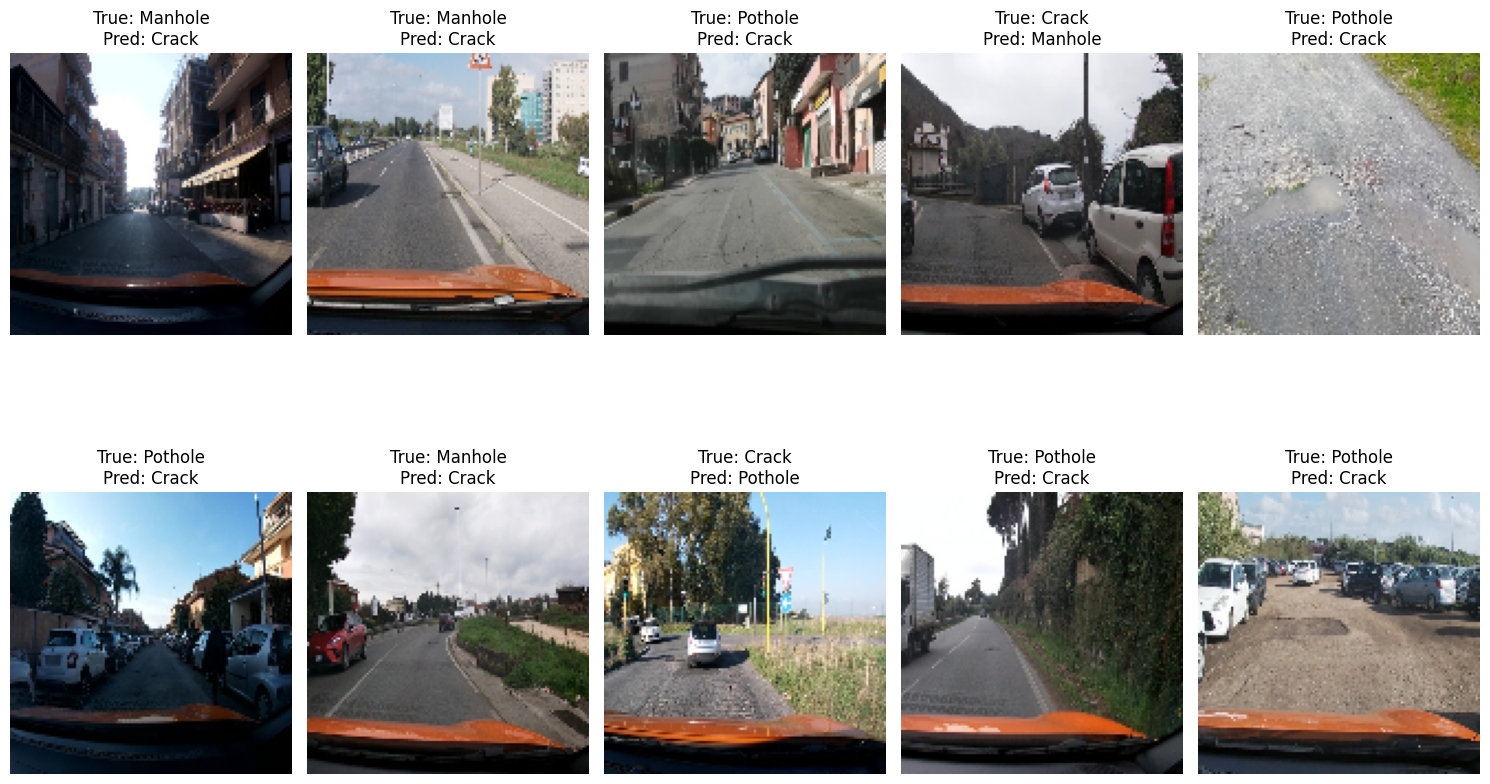

In [55]:
misclassified_idx = np.where(y_pred != y_test)[0]
plt.figure(figsize=(15, 10))

# Show first 10 misclassified images
for i, idx in enumerate(misclassified_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Task 9: Save the CNN Model
Finally, we export the model and label mappings for future use or deployment.

In [56]:
import json

# Save the model in Keras format
model.save('road_damage_detector.keras')

# Save the class names/mapping
labels_map = {i: name for i, name in enumerate(class_names)}
with open('label_map.json', 'w') as f:
    json.dump(labels_map, f)

print("Model and label mappings saved successfully!")

Model and label mappings saved successfully!


### Task 8: Real-Time Prediction
This function allows you to test the model on a specific image and visualize the prediction results.

Testing on: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data/images/vlcsnap-2025-02-26-20h42m15s464.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


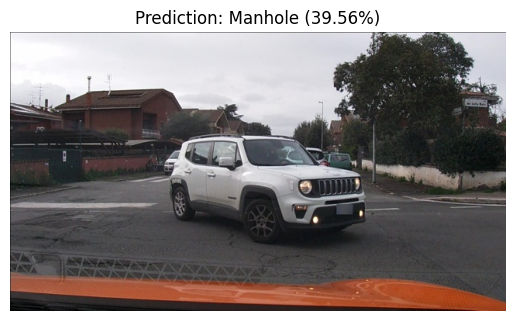

In [57]:
def predict_road_damage(img_path):
    # Load and preprocess image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (128, 128))
    img_normalized = img_resized.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Predict
    prediction = model.predict(img_batch)
    class_idx = np.argmax(prediction)
    confidence = prediction[0][class_idx]

    # Display
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[class_idx]} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

# Test on a random image from the dataset folder
import random
test_sample_path = random.choice(image_files)
print(f"Testing on: {test_sample_path}")
predict_road_damage(test_sample_path)

### Task 8: Real-Time Prediction
This function demonstrates how the model can be used to predict road damage on individual, unseen images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


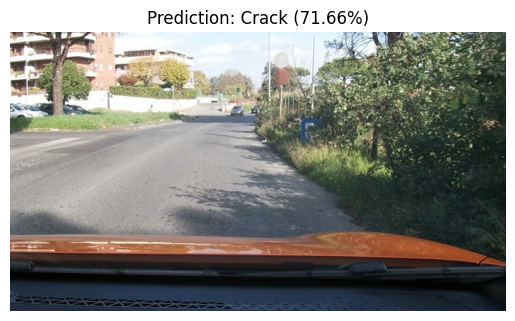

In [58]:
def predict_road_damage(img_path):
    # Load and preprocess image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (128, 128))
    img_normalized = img_resized.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Predict
    prediction = model.predict(img_batch)
    class_idx = np.argmax(prediction)
    confidence = prediction[0][class_idx]

    # Display
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[class_idx]} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

# Test on a sample from the dataset
test_sample_path = image_files[1005]
predict_road_damage(test_sample_path)

### Task 8: Real-Time Prediction
This function demonstrates how the model can be used to predict road damage on individual, unseen images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


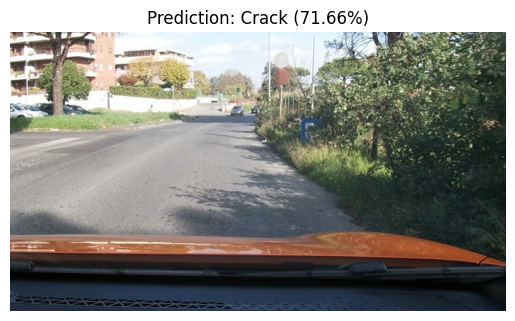

In [59]:
def predict_road_damage(img_path):
    # Load and preprocess image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (128, 128))
    img_normalized = img_resized.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Predict
    prediction = model.predict(img_batch)
    class_idx = np.argmax(prediction)
    confidence = prediction[0][class_idx]

    # Display
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[class_idx]} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

# Test on a sample from the dataset
test_sample_path = image_files[1005]
predict_road_damage(test_sample_path)

### Task 7: Failure Analysis (Visualizing Misclassifications)
Identifying and displaying images where the model's prediction did not match the actual label.

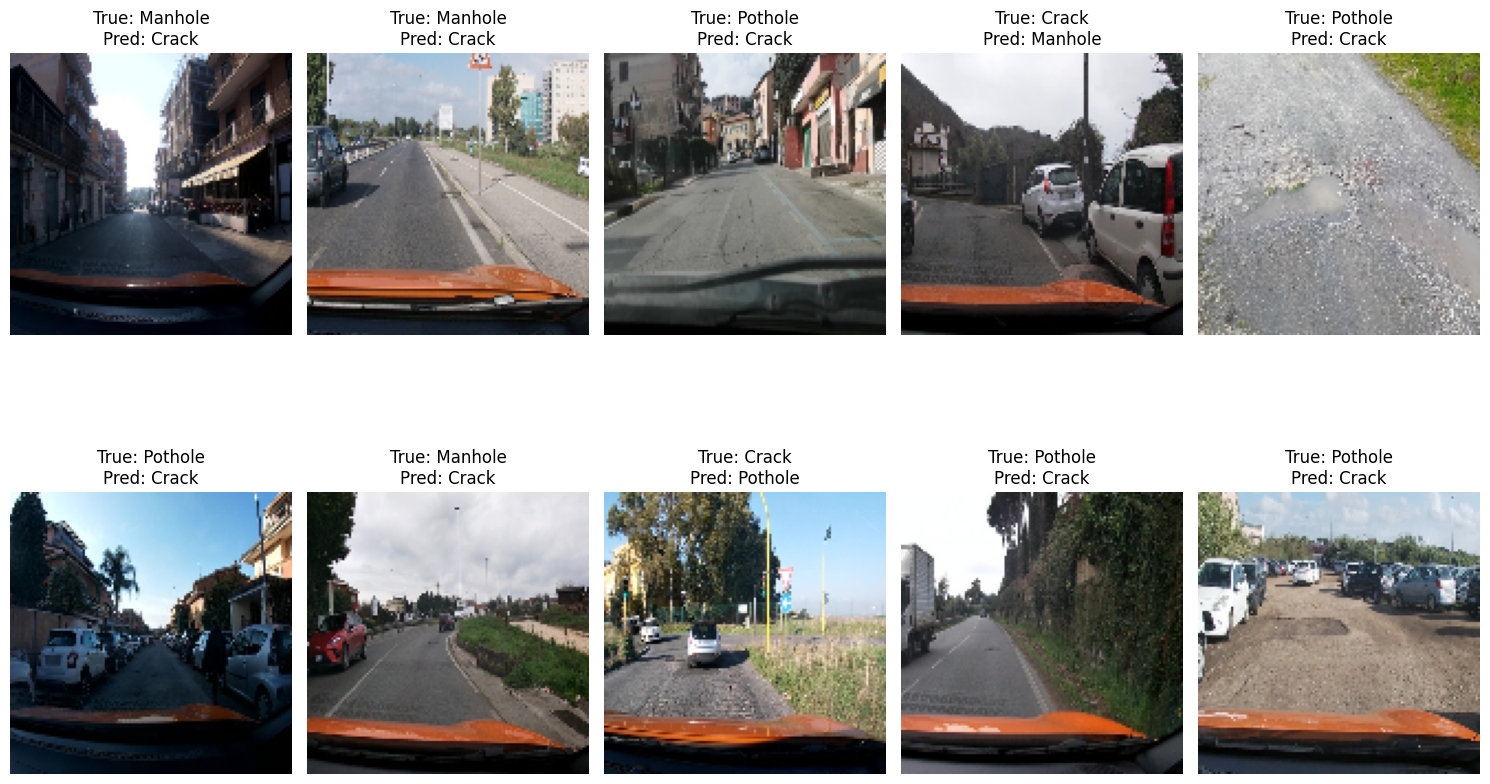

In [60]:
misclassified_idx = np.where(y_pred != y_test)[0]
plt.figure(figsize=(15, 10))

# Show first 10 misclassified images
for i, idx in enumerate(misclassified_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Task 9: Save the CNN Model
Exporting the model for future use.

In [61]:
import json

# Save the model in Keras format
model.save('road_damage_detector.keras')

# Save the class names/mapping
labels_map = {i: name for i, name in enumerate(class_names)}
with open('label_map.json', 'w') as f:
    json.dump(labels_map, f)

print("Model and label mappings saved successfully!")

Model and label mappings saved successfully!


### Task 8: Real-Time Prediction
This function allows you to pass an image to the model and get a prediction for road damage.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


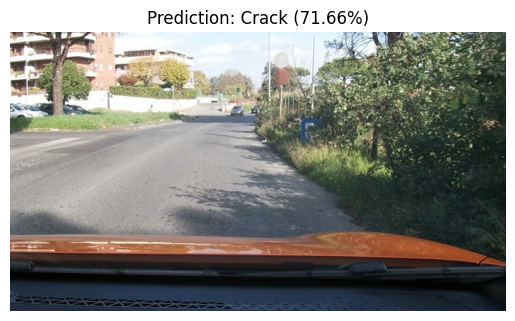

In [62]:
def predict_road_damage(img_path):
    # Load and preprocess image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (128, 128))
    img_normalized = img_resized.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0)

    # Predict
    prediction = model.predict(img_batch)
    class_idx = np.argmax(prediction)
    confidence = prediction[0][class_idx]

    # Display
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[class_idx]} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

# Test on a random image from the test set
test_sample_path = image_files[1005]
predict_road_damage(test_sample_path)